# Licenciatura en Ciencia de Datos
## Calidad y Preprocesamiento de Datos

---

### **Proyecto Final — Fusión y Visualización**

**Equipo**

**Castrillo Cruz Karen Arlet**

**Pérez Aguiar Oropeza Gabriel Emiliano**

**Ramos González Nadia**

**Rueda Reyes Fabián**

**Torres Pasión Angel Isaac**


### **Objetivo**

Fusionar las bases INE y BANAVIM mediante Record Linkage (Sorted Neighbourhood Method) y generar el perfil estadístico integrado de violencia por municipio y estado. Este notebook requiere los outputs de `limpieza.ipynb`:

- `ine_incidencias_2020_2022.csv`
- `banavim_fix_2020_2022.pkl`
- `df_golden.pkl`


## 0. Configuración


In [1]:
# Instalación de dependencias
!pip install recordlinkage fuzzywuzzy python-Levenshtein jellyfish \
            unidecode networkx geopy openpyxl scikit-learn --quiet


In [2]:
import pandas as pd
import numpy as np
import re
import pickle
from pathlib import Path
from unicodedata import normalize
from unidecode import unidecode

import recordlinkage
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from matplotlib.patches import Patch

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
sns.set_theme(style='whitegrid')

print('Entorno listo')


Entorno listo


In [3]:
# Rutas base — funciona en Windows y Linux/macOS
DATA_DIR = Path('..') / 'Data'
PKL_DIR  = Path('.')   # los pkl viven en el mismo directorio que el notebook

DATA_DIR.mkdir(parents=True, exist_ok=True)
(DATA_DIR / 'fusion_outputs').mkdir(parents=True, exist_ok=True)

print('DATA_DIR:', DATA_DIR.resolve())
print('PKL_DIR :', PKL_DIR.resolve())


DATA_DIR: /home/emi/Desktop/Calidad-y-Preprocesamiento-de-Datos---Registro-Publico-de-Agresores/Data
PKL_DIR : /home/emi/Desktop/Calidad-y-Preprocesamiento-de-Datos---Registro-Publico-de-Agresores/Código


In [4]:
# Cargar outputs de limpieza.ipynb
# Asegúrate de haber ejecutado limpieza.ipynb antes de correr este notebook.

# INE limpio y filtrado (2020-2022)
ine = pd.read_csv(DATA_DIR / 'ine_incidencias_2020_2022.csv', encoding='utf-8-sig')
ine['fecha_resolucion'] = pd.to_datetime(ine['fecha_resolucion'], errors='coerce')
print(f'INE cargado: {ine.shape}')

# BANAVIM con texto reparado (mojibake corregido)
with open(DATA_DIR / 'banavim_fix_2020_2022.pkl', 'rb') as _f:
    bv_fix = pickle.load(_f)
print(f'bv_fix cargado: {bv_fix.shape}')

# Golden Record INE consolidado
with open(DATA_DIR / 'df_golden.pkl', 'rb') as _f:
    df_golden = pickle.load(_f)
print(f'df_golden cargado: {df_golden.shape}')


INE cargado: (162, 25)
bv_fix cargado: (806092, 36)
df_golden cargado: (140, 27)


### 3.2 Perfilado de candidatos para fusión

In [5]:
# Correspondencia entre columnas originales BANAVIM y columnas normalizadas
pares_banavim = [
    ('Estado donde reside',             'estado'),
    ('Municipio donde reside',           'municipio'),
    ('Sexo',                             'sexo'),
    ('Edad del Agresor',                 'edad'),
    ('Escolaridad',                      'escolaridad'),
    ('Estado Civil',                     'estado_civil'),
    ('Relación o vículo con la víctima', 'vinculo_victima'),
    ('Fecha de registro',                'fecha_registro'),
]

comparacion_pares_bv = []
for orig, der in pares_banavim:
    if orig in bv_fix.columns and der in bv_fix.columns:
        comparacion_pares_bv.append({
            'columna_original': orig, 'columna_derivada': der,
            'nulos_original': bv_fix[orig].isna().sum(),
            'nulos_derivada': bv_fix[der].isna().sum(),
            'unicos_original': bv_fix[orig].nunique(dropna=True),
            'unicos_derivada': bv_fix[der].nunique(dropna=True),
            'ejemplo_original': bv_fix[orig].dropna().astype(str).iloc[0] if bv_fix[orig].notna().any() else None,
            'ejemplo_derivada': bv_fix[der].dropna().astype(str).iloc[0] if bv_fix[der].notna().any() else None,
        })
display(pd.DataFrame(comparacion_pares_bv))

,columna_original,columna_derivada,nulos_original,nulos_derivada,unicos_original,unicos_derivada,ejemplo_original,ejemplo_derivada
0,Estado donde reside,estado,22,22,33,33,Aguascalientes,AGUASCALIENTES
1,Municipio donde reside,municipio,22,22,1945,1945,Aguascalientes,Aguascalientes
2,Sexo,sexo,141475,141475,3,3,Hombre,Hombre
3,Edad del Agresor,edad,144484,144484,97,97,34,34.0
4,Escolaridad,escolaridad,135372,135372,13,13,No identificado,No identificado
5,Estado Civil,estado_civil,404073,404073,10,10,Unión libre,Unión libre
6,Relación o vículo con la víctima,vinculo_victima,130927,130927,23,23,Ex pareja,Ex pareja
7,Fecha de registro,fecha_registro,0,0,756919,756919,2020-09-03 08:59:29,2020-09-03 08:59:29


In [6]:
# Perfilado de campos categóricos candidatos para fusión en INE
campos_ine_fusion = ['Sexo', 'entidad', 'Municipio', 'Relación Con La Víctima']
campos_ine_fusion = [c for c in campos_ine_fusion if c in ine.columns]

resumen_cat_ine = []
for col in campos_ine_fusion:
    resumen_cat_ine.append({
        'campo': col, 'registros': len(ine),
        'no_nulos': ine[col].notna().sum(), 'missing': ine[col].isna().sum(),
        'completitud_%': round(ine[col].notna().mean() * 100, 2),
        'valores_unicos': ine[col].nunique(dropna=True)
    })
resumen_cat_ine = pd.DataFrame(resumen_cat_ine)
display(resumen_cat_ine)

distincts_ine = []
for col in campos_ine_fusion:
    tmp = ine[col].value_counts(dropna=False).reset_index()
    tmp.columns = ['valor', 'frecuencia']
    tmp.insert(0, 'campo', col)
    tmp['porcentaje'] = (tmp['frecuencia'] / len(ine) * 100).round(2)
    distincts_ine.append(tmp)
distincts_ine = pd.concat(distincts_ine, ignore_index=True)
display(distincts_ine)

resumen_cat_ine.to_csv(DATA_DIR / 'resumen_categoricos_ine_fusion.csv', index=False, encoding='utf-8-sig')
distincts_ine.to_csv(DATA_DIR / 'distincts_categoricos_ine_fusion.csv', index=False, encoding='utf-8-sig')
print('Perfilado INE guardado.')

,campo,registros,no_nulos,missing,completitud_%,valores_unicos
0,Sexo,162,162,0,100.00,2
1,entidad,162,162,0,100.00,18
2,Municipio,162,129,33,79.63,59
3,Relación Con La Víctima,162,162,0,100.00,7


,campo,valor,frecuencia,porcentaje
0,Sexo,Hombre,136,83.95
1,Sexo,Mujer,26,16.05
2,entidad,OAXACA,65,40.12
3,entidad,VERACRUZ,22,13.58
4,entidad,TABASCO,19,11.73
...,...,...,...,...
82,Relación Con La Víctima,Jerárquica,33,20.37
83,Relación Con La Víctima,Subordinación,5,3.09
84,Relación Con La Víctima,Otro,3,1.85
85,Relación Con La Víctima,Opositor en la contienda,2,1.23


Perfilado INE guardado.


### 3.3 Normalización y bases para fusión

In [7]:
# 3.3 Funciones de normalización para campos de fusión

NULOS_SEMANTICOS = {
    '', 'NAN', 'NONE', 'NULL', 'NA', 'N/A',
    'SIN DATO', 'SIN DATOS',
    'NO ESPECIFICADO', 'NO ESPECIFICADA', 'NO SE ESPECIFICA',
    'SE IGNORA', 'IGNORADO', 'IGNORADA',
    'NO APLICA', 'NO APLICA.',
    'INDETERMINADO', 'INDETERMINADA'
}

def normalizar_categoria_fusion(x):
    if pd.isna(x): return np.nan
    s = str(x).strip()
    if s == '': return np.nan
    s = unidecode(s).upper()
    s = re.sub(r'[^A-Z0-9\s]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return np.nan if s in NULOS_SEMANTICOS else s

def normalizar_sexo_fusion(x):
    s = normalizar_categoria_fusion(x)
    if pd.isna(s): return np.nan
    return {'H':'H','HOMBRE':'H','MASCULINO':'H','M':'M','MUJER':'M','F':'M','FEMENINO':'M'}.get(s, s)

print('Funciones de normalización para fusión definidas')

Funciones de normalización para fusión definidas


In [8]:
# 7.2 Crear base INE orientada a fusión
ine_fusion = ine.copy()
if 'id_ine_caso' not in ine_fusion.columns:
    ine_fusion['id_ine_caso'] = 'INE_' + ine_fusion.index.astype(str).str.zfill(5)

ine_fusion['sexo']           = ine_fusion['Sexo'].apply(normalizar_sexo_fusion)
ine_fusion['estado']         = ine_fusion['entidad'].apply(normalizar_categoria_fusion)
ine_fusion['municipio']      = ine_fusion['Municipio'].apply(normalizar_categoria_fusion)
ine_fusion['vinculo_victima']= ine_fusion['Relación Con La Víctima'].apply(normalizar_categoria_fusion)
ine_fusion['anio_resolucion']= ine_fusion['fecha_resolucion'].dt.year

cols_keep = [c for c in ['id_ine_caso','Nombre','Número De Expediente',
             'fecha_resolucion','anio_resolucion','sexo','estado',
             'municipio','vinculo_victima'] if c in ine_fusion.columns]
ine_fusion = ine_fusion[cols_keep].copy()

display(ine_fusion.head())
print(f'ine_fusion: {ine_fusion.shape}')

,id_ine_caso,Nombre,Número De Expediente,fecha_resolucion,anio_resolucion,sexo,estado,municipio,vinculo_victima
0,INE_00000,AARÓN VEGA REA,SRE-PSC-41/2022,2022-04-07,2022,H,GUANAJUATO,NaN,NINGUNA
1,INE_00001,ABEL TOVILLA CARPIO,IEPC/PE/GJMA/081/2021,2021-11-10,2021,H,CHIAPAS,TEOPISCA,PARES
2,INE_00002,ADÁN FRAUSTO ARELLANO,TEE-PES-18/2021,2021-07-02,2021,H,NAYARIT,EL NAYAR,JERARQUICA
3,INE_00003,ADRIANA AVENDAÑO NIÑO,PES-58/2021,2021-06-04,2021,M,OAXACA,SAN ANDRES ZAUTLA,NINGUNA
4,INE_00004,ALBERTO ALFONSO MENDOZA CRUZ,JDCI/52/2021 y su acumulado JDCI/56/2021,2021-07-09,2021,H,OAXACA,SAN LORENZO CACAOTEPEC,JERARQUICA


ine_fusion: (162, 9)


In [9]:
# 7.3 Perfilado de campos canónicos INE para fusión
campos_ine_canon = ['sexo', 'estado', 'municipio', 'vinculo_victima']
resumen_ine_canon = []
for col in campos_ine_canon:
    resumen_ine_canon.append({
        'campo': col, 'registros': len(ine_fusion),
        'no_nulos': ine_fusion[col].notna().sum(),
        'missing': ine_fusion[col].isna().sum(),
        'completitud_%': round(ine_fusion[col].notna().mean() * 100, 2),
        'valores_unicos': ine_fusion[col].nunique(dropna=True)
    })
display(pd.DataFrame(resumen_ine_canon))

,campo,registros,no_nulos,missing,completitud_%,valores_unicos
0,sexo,162,162,0,100.00,2
1,estado,162,162,0,100.00,18
2,municipio,162,129,33,79.63,59
3,vinculo_victima,162,162,0,100.00,7


In [10]:
# bv_fusion: base BANAVIM orientada a fusión
bv_fusion = bv_fix.copy()
if 'id_bv_caso' not in bv_fusion.columns:
    bv_fusion['id_bv_caso'] = 'BV_' + bv_fusion.index.astype(str).str.zfill(7)

bv_fusion['sexo']           = bv_fusion['sexo'].apply(normalizar_sexo_fusion)
bv_fusion['estado']         = bv_fusion['estado'].apply(normalizar_categoria_fusion)
bv_fusion['municipio']      = bv_fusion['municipio'].apply(normalizar_categoria_fusion)
bv_fusion['vinculo_victima']= bv_fusion['vinculo_victima'].apply(normalizar_categoria_fusion)
bv_fusion['anio_registro']  = pd.to_datetime(bv_fusion['fecha_registro'], errors='coerce').dt.year

cols_bv = [c for c in ['id_bv_caso','Identificador Único','año_base',
           'fecha_registro','anio_registro','sexo','estado',
           'municipio','vinculo_victima'] if c in bv_fusion.columns]
bv_fusion = bv_fusion[cols_bv].copy()

display(bv_fusion.head())
print(f'bv_fusion: {bv_fusion.shape}')

,id_bv_caso,Identificador Único,año_base,fecha_registro,anio_registro,sexo,estado,municipio,vinculo_victima
0,BV_0000000,0128900022-2,2020,2020-09-03 08:59:29,2020,H,AGUASCALIENTES,AGUASCALIENTES,EX PAREJA
1,BV_0000001,0128900106-2,2020,2020-10-20 09:25:05,2020,H,AGUASCALIENTES,AGUASCALIENTES,CONYUGE O PAREJA
2,BV_0000002,0128900132-2,2020,2020-07-02 08:07:24,2020,H,AGUASCALIENTES,AGUASCALIENTES,CONYUGE O PAREJA
3,BV_0000003,0128900350-2,2020,2020-01-29 15:48:51,2020,H,AGUASCALIENTES,AGUASCALIENTES,EX PAREJA
4,BV_0000004,0128900563-2,2020,2020-12-07 13:50:38,2020,H,AGUASCALIENTES,COSIO,CONYUGE O PAREJA


bv_fusion: (806092, 9)


In [11]:
# Perfilado de campos canónicos BANAVIM para fusión
resumen_bv_fusion = []
for col in ['sexo', 'estado', 'municipio', 'vinculo_victima']:
    resumen_bv_fusion.append({
        'campo': col, 'registros': len(bv_fusion),
        'no_nulos': bv_fusion[col].notna().sum(),
        'missing': bv_fusion[col].isna().sum(),
        'completitud_%': round(bv_fusion[col].notna().mean() * 100, 2),
        'valores_unicos': bv_fusion[col].nunique(dropna=True)
    })
display(pd.DataFrame(resumen_bv_fusion))

,campo,registros,no_nulos,missing,completitud_%,valores_unicos
0,sexo,806092,664617,141475,82.45,3
1,estado,806092,806070,22,100.00,33
2,municipio,806092,806070,22,100.00,1945
3,vinculo_victima,806092,675165,130927,83.76,23


In [12]:
# Distribución de vínculo en BANAVIM y comparación con INE
distincts_vinculo_bv = bv_fusion['vinculo_victima'].value_counts(dropna=False).reset_index()
distincts_vinculo_bv.columns = ['vinculo_victima', 'frecuencia']
distincts_vinculo_bv['porcentaje'] = (distincts_vinculo_bv['frecuencia'] / len(bv_fusion) * 100).round(2)
display(distincts_vinculo_bv)

vinculos_ine = ine_fusion['vinculo_victima'].value_counts(dropna=False).reset_index()
vinculos_ine.columns = ['valor', 'frecuencia_ine']
vinculos_ine['porcentaje_ine'] = (vinculos_ine['frecuencia_ine'] / len(ine_fusion) * 100).round(2)

vinculos_bv = bv_fusion['vinculo_victima'].value_counts(dropna=False).reset_index()
vinculos_bv.columns = ['valor', 'frecuencia_banavim']
vinculos_bv['porcentaje_banavim'] = (vinculos_bv['frecuencia_banavim'] / len(bv_fusion) * 100).round(2)

comparacion_vinculos = vinculos_ine.merge(vinculos_bv, on='valor', how='outer', indicator=True)
comparacion_vinculos['aparece_en'] = comparacion_vinculos['_merge'].map(
    {'left_only': 'solo INE', 'right_only': 'solo BANAVIM', 'both': 'ambas'})
cols_num = ['frecuencia_ine','porcentaje_ine','frecuencia_banavim','porcentaje_banavim']
comparacion_vinculos[cols_num] = comparacion_vinculos[cols_num].fillna(0)
display(comparacion_vinculos.drop(columns='_merge')
        .sort_values(['aparece_en','frecuencia_banavim'], ascending=[True,False]))

,vinculo_victima,frecuencia,porcentaje
0,CONYUGE O PAREJA,296188,36.74
1,EX PAREJA,151341,18.77
2,NaN,130927,16.24
3,SELECCIONE,78554,9.75
4,OTRO,31138,3.86
5,HIJO A,23839,2.96
6,MADRE O PADRE,23766,2.95
7,HERMANO A,15065,1.87
8,CONCUBINA,13298,1.65
9,VECINO A,11678,1.45


,valor,frecuencia_ine,porcentaje_ine,frecuencia_banavim,porcentaje_banavim,aparece_en
9,JERARQUICA,33.0,20.37,0.0,0.00,solo INE
12,NINGUNA,57.0,35.19,0.0,0.00,solo INE
14,OPOSITOR EN LA CONTIENDA,2.0,1.23,0.0,0.00,solo INE
15,OTRA,1.0,0.62,0.0,0.00,solo INE
19,PARES,61.0,37.65,0.0,0.00,solo INE
25,SUBORDINACION,5.0,3.09,0.0,0.00,solo INE
3,CONYUGE O PAREJA,0.0,0.00,296188.0,36.74,solo BANAVIM
5,EX PAREJA,0.0,0.00,151341.0,18.77,solo BANAVIM
29,NaN,0.0,0.00,130927.0,16.24,solo BANAVIM
22,SELECCIONE,0.0,0.00,78554.0,9.75,solo BANAVIM


### 3.4 Homologación semántica del vínculo con la víctima

In [13]:
# 3.4 Mapas semánticos de vínculo con la víctima
NULOS_SEMANTICOS.update({
    'SELECCIONE', 'SELECCIONA', 'SELECCIONAR',
    'SIN ESPECIFICAR', 'SIN DATO', 'SIN DATOS',
    'NO ESPECIFICADO', 'NO ESPECIFICADA', 'NO SE ESPECIFICA'
})

MAPA_VINCULO_INE = {
    'PARES': 'PARES',
    'JERARQUICA': 'JERARQUICA_SUBORDINACION',
    'SUBORDINACION': 'JERARQUICA_SUBORDINACION',
    'OPOSITOR EN LA CONTIENDA': 'INSTITUCIONAL_POLITICA',
    'OTRO': 'OTRO', 'OTRA': 'OTRO', 'OTRA RELACION': 'OTRO',
    'NINGUNA': 'NINGUNA',
}

MAPA_VINCULO_BANAVIM = {
    'COMPANERO A': 'PARES', 'COMPANERO': 'PARES', 'COMPANERA': 'PARES',
    'COMPANERO DE TRABAJO': 'PARES', 'COMPANERA DE TRABAJO': 'PARES',
    'JEFE A': 'JERARQUICA_SUBORDINACION', 'JEFE': 'JERARQUICA_SUBORDINACION',
    'JEFA': 'JERARQUICA_SUBORDINACION', 'PATRON A': 'JERARQUICA_SUBORDINACION',
    'PATRON': 'JERARQUICA_SUBORDINACION', 'PATRONA': 'JERARQUICA_SUBORDINACION',
    'SUPERIOR': 'JERARQUICA_SUBORDINACION', 'SUPERIOR JERARQUICO': 'JERARQUICA_SUBORDINACION',
    'DIRECTOR A': 'JERARQUICA_SUBORDINACION', 'DIRECTOR': 'JERARQUICA_SUBORDINACION',
    'JEFE A O PATRON A': 'JERARQUICA_SUBORDINACION',
    'SERVIDOR PUBLICO': 'INSTITUCIONAL_POLITICA', 'SERVIDORA PUBLICA': 'INSTITUCIONAL_POLITICA',
    'FUNCIONARIO PUBLICO': 'INSTITUCIONAL_POLITICA', 'AUTORIDAD PUBLICA': 'INSTITUCIONAL_POLITICA',
    'AUTORIDAD': 'INSTITUCIONAL_POLITICA',
    'OTRO': 'OTRO', 'OTRA': 'OTRO', 'OTRA RELACION': 'OTRO', 'OTRO TIPO DE RELACION': 'OTRO',
    'CONYUGE O PAREJA': 'PAREJA_EXPAREJA', 'CONYUGE': 'PAREJA_EXPAREJA', 'PAREJA': 'PAREJA_EXPAREJA',
    'ESPOSO': 'PAREJA_EXPAREJA', 'ESPOSA': 'PAREJA_EXPAREJA',
    'EX PAREJA': 'PAREJA_EXPAREJA', 'EXPAREJA': 'PAREJA_EXPAREJA',
    'EX CONYUGE': 'PAREJA_EXPAREJA', 'NOVIO A': 'PAREJA_EXPAREJA',
    'NOVIO': 'PAREJA_EXPAREJA', 'NOVIA': 'PAREJA_EXPAREJA',
    'EX NOVIO A': 'PAREJA_EXPAREJA', 'EX NOVIO': 'PAREJA_EXPAREJA',
    'HIJO A': 'FAMILIAR', 'HIJO': 'FAMILIAR', 'HIJA': 'FAMILIAR',
    'MADRE O PADRE': 'FAMILIAR', 'MADRE': 'FAMILIAR', 'PADRE': 'FAMILIAR',
    'HERMANO A': 'FAMILIAR', 'HERMANO': 'FAMILIAR', 'HERMANA': 'FAMILIAR',
    'ABUELO A': 'FAMILIAR', 'TIO A': 'FAMILIAR', 'TIO': 'FAMILIAR', 'TIA': 'FAMILIAR',
    'PRIMO A': 'FAMILIAR', 'PRIMO': 'FAMILIAR', 'PRIMA': 'FAMILIAR', 'FAMILIAR': 'FAMILIAR',
    'VECINO A': 'COMUNITARIO_SOCIAL', 'VECINO': 'COMUNITARIO_SOCIAL', 'VECINA': 'COMUNITARIO_SOCIAL',
    'CONOCIDO A': 'COMUNITARIO_SOCIAL', 'CONOCIDO': 'COMUNITARIO_SOCIAL',
    'AMIGO A': 'COMUNITARIO_SOCIAL', 'AMIGO': 'COMUNITARIO_SOCIAL', 'AMIGA': 'COMUNITARIO_SOCIAL',
    'DESCONOCIDO A': 'COMUNITARIO_SOCIAL', 'DESCONOCIDO': 'COMUNITARIO_SOCIAL',
    'PROFESOR A': 'COMUNITARIO_SOCIAL', 'MAESTRO A': 'COMUNITARIO_SOCIAL',
    'TUTOR A': 'COMUNITARIO_SOCIAL', 'CUIDADOR A': 'COMUNITARIO_SOCIAL',
}

In [14]:
def homologar_vinculo(x, mapa):
    """
    Asigna una categoría semántica común al vínculo con la víctima.
    Devuelve MISSING si el valor es nulo/placeholder, REVISAR si no está en el mapa.
    """
    s = normalizar_categoria_fusion(x)
    if pd.isna(s): return 'MISSING'
    if s in NULOS_SEMANTICOS: return 'MISSING'
    return mapa.get(s, 'REVISAR')

In [15]:
# Aplicar homologación a INE y BANAVIM
ine_fusion['vinculo_grupo'] = ine_fusion['vinculo_victima'].apply(
    lambda x: homologar_vinculo(x, MAPA_VINCULO_INE))
bv_fusion['vinculo_grupo']  = bv_fusion['vinculo_victima'].apply(
    lambda x: homologar_vinculo(x, MAPA_VINCULO_BANAVIM))

In [16]:
# Conteos de categorías homologadas
def conteo_grupos_vinculo(df, nombre_base):
    conteo = df['vinculo_grupo'].value_counts(dropna=False).reset_index()
    conteo.columns = ['vinculo_grupo', 'frecuencia']
    conteo['porcentaje'] = (conteo['frecuencia'] / len(df) * 100).round(2)
    conteo.insert(0, 'base', nombre_base)
    return conteo

conteo_vinculo_ine = conteo_grupos_vinculo(ine_fusion, 'INE')
conteo_vinculo_bv  = conteo_grupos_vinculo(bv_fusion, 'BANAVIM')
conteo_vinculos    = pd.concat([conteo_vinculo_ine, conteo_vinculo_bv], ignore_index=True)
display(conteo_vinculos)

,base,vinculo_grupo,frecuencia,porcentaje
0,INE,PARES,61,37.65
1,INE,NINGUNA,57,35.19
2,INE,JERARQUICA_SUBORDINACION,38,23.46
3,INE,OTRO,4,2.47
4,INE,INSTITUCIONAL_POLITICA,2,1.23
5,BANAVIM,PAREJA_EXPAREJA,452936,56.19
6,BANAVIM,MISSING,209481,25.99
7,BANAVIM,FAMILIAR,71860,8.91
8,BANAVIM,OTRO,31139,3.86
9,BANAVIM,REVISAR,24084,2.99


In [17]:
# Comparación de grupos homologados entre INE y BANAVIM
comparacion_grupos_vinculo = conteo_vinculo_ine.merge(
    conteo_vinculo_bv, on='vinculo_grupo', how='outer', suffixes=('_ine', '_banavim'))
cols_num = ['frecuencia_ine','porcentaje_ine','frecuencia_banavim','porcentaje_banavim']
comparacion_grupos_vinculo[cols_num] = comparacion_grupos_vinculo[cols_num].fillna(0)
display(comparacion_grupos_vinculo[['vinculo_grupo'] + cols_num].sort_values('vinculo_grupo'))

,vinculo_grupo,frecuencia_ine,porcentaje_ine,frecuencia_banavim,porcentaje_banavim
0,COMUNITARIO_SOCIAL,0.0,0.00,12235.0,1.52
1,FAMILIAR,0.0,0.00,71860.0,8.91
2,INSTITUCIONAL_POLITICA,2.0,1.23,515.0,0.06
3,JERARQUICA_SUBORDINACION,38.0,23.46,1927.0,0.24
4,MISSING,0.0,0.00,209481.0,25.99
5,NINGUNA,57.0,35.19,0.0,0.00
6,OTRO,4.0,2.47,31139.0,3.86
7,PAREJA_EXPAREJA,0.0,0.00,452936.0,56.19
8,PARES,61.0,37.65,1915.0,0.24
9,REVISAR,0.0,0.00,24084.0,2.99


In [18]:
# Valores que quedaron en REVISAR
for base_name, df_base in [('INE', ine_fusion), ('BANAVIM', bv_fusion)]:
    print(f'{base_name} — valores en REVISAR')
    revisar = (
        df_base.loc[df_base['vinculo_grupo'].eq('REVISAR'), 'vinculo_victima']
        .value_counts(dropna=False).reset_index()
    )
    revisar.columns = ['valor', 'frecuencia']
    display(revisar)
    print(f'{base_name} — valores en MISSING')
    missing = (
        df_base.loc[df_base['vinculo_grupo'].eq('MISSING'), 'vinculo_victima']
        .value_counts(dropna=False).reset_index()
    )
    missing.columns = ['valor', 'frecuencia']
    display(missing)

INE — valores en REVISAR


,valor,frecuencia


INE — valores en MISSING


,valor,frecuencia


BANAVIM — valores en REVISAR


,valor,frecuencia
0,CONCUBINA,13298
1,PADRASTRO O MADRASTRA,5272
2,SOBRINO A,2468
3,SUEGRO A,1765
4,NIETO A,1281


BANAVIM — valores en MISSING


,valor,frecuencia
0,NaN,130927
1,SELECCIONE,78554


In [19]:
# Ajustes al mapa BANAVIM tras revisar valores en REVISAR
MAPA_VINCULO_BANAVIM.update({
    'CONCUBINA': 'PAREJA_EXPAREJA', 'CONCUBINO': 'PAREJA_EXPAREJA',
    'PADRASTRO O MADRASTRA': 'FAMILIAR', 'PADRASTRO': 'FAMILIAR', 'MADRASTRA': 'FAMILIAR',
    'SOBRINO A': 'FAMILIAR', 'SOBRINO': 'FAMILIAR', 'SOBRINA': 'FAMILIAR',
    'SUEGRO A': 'FAMILIAR', 'SUEGRA': 'FAMILIAR',
    'NIETO A': 'FAMILIAR', 'NIETO': 'FAMILIAR', 'NIETA': 'FAMILIAR',
})

In [20]:
# Recalcular homologación con el mapa actualizado
ine_fusion['vinculo_grupo'] = ine_fusion['vinculo_victima'].apply(
    lambda x: homologar_vinculo(x, MAPA_VINCULO_INE))
bv_fusion['vinculo_grupo']  = bv_fusion['vinculo_victima'].apply(
    lambda x: homologar_vinculo(x, MAPA_VINCULO_BANAVIM))

for base_name, df_base in [('INE', ine_fusion), ('BANAVIM', bv_fusion)]:
    revisar_n = df_base['vinculo_grupo'].eq('REVISAR').sum()
    print(f'{base_name} — valores aún en REVISAR: {revisar_n}')

INE — valores aún en REVISAR: 0
BANAVIM — valores aún en REVISAR: 0


In [21]:
# Comparación de vocabularios entre INE y BANAVIM
campos_comparables = ['sexo', 'estado', 'municipio', 'vinculo_grupo']
comparacion_vocabularios = []
for col in campos_comparables:
    vals_ine = set(ine_fusion[col].dropna().unique())
    vals_bv  = set(bv_fusion[col].dropna().unique())
    inter    = vals_ine & vals_bv
    comparacion_vocabularios.append({
        'campo': col,
        'unicos_ine': len(vals_ine), 'unicos_banavim': len(vals_bv),
        'coincidentes': len(inter),
        'solo_ine': len(vals_ine - vals_bv), 'solo_banavim': len(vals_bv - vals_ine),
        'pct_ine_cubierto': round(len(inter)/len(vals_ine)*100, 2) if vals_ine else np.nan,
        'pct_banavim_cubierto': round(len(inter)/len(vals_bv)*100, 2) if vals_bv else np.nan,
    })
comparacion_vocabularios = pd.DataFrame(comparacion_vocabularios)
display(comparacion_vocabularios)

,campo,unicos_ine,unicos_banavim,coincidentes,solo_ine,solo_banavim,pct_ine_cubierto,pct_banavim_cubierto
0,sexo,2,3,2,0,1,100.00,66.67
1,estado,18,33,14,4,19,77.78,42.42
2,municipio,59,1945,52,7,1893,88.14,2.67
3,vinculo_grupo,5,8,4,1,4,80.00,50.00


In [22]:
# Revisar valores de sexo y estado antes del ajuste final
for base_name, df_base in [('INE', ine_fusion), ('BANAVIM', bv_fusion)]:
    print(f'\n{base_name} — sexo')
    s = df_base['sexo'].value_counts(dropna=False).reset_index()
    s.columns = ['sexo', 'frecuencia']
    s['porcentaje'] = (s['frecuencia'] / len(df_base) * 100).round(2)
    display(s)
    print(f'{base_name} — estado (top 10)')
    e = df_base['estado'].value_counts(dropna=False).head(10).reset_index()
    e.columns = ['estado', 'frecuencia']
    display(e)


INE — sexo


,sexo,frecuencia,porcentaje
0,H,136,83.95
1,M,26,16.05


INE — estado (top 10)


,estado,frecuencia
0,OAXACA,65
1,VERACRUZ,22
2,TABASCO,19
3,CHIAPAS,8
4,BAJA CALIFORNIA SUR,7
5,MORELOS,6
6,NAYARIT,6
7,SAN LUIS POTOSI,5
8,PUEBLA,5
9,GUANAJUATO,4



BANAVIM — sexo


,sexo,frecuencia,porcentaje
0,H,634075,78.66
1,NaN,141475,17.55
2,M,29651,3.68
3,OTRO ESPECIFIQUE,891,0.11


BANAVIM — estado (top 10)


,estado,frecuencia
0,QUINTANA ROO,123036
1,JALISCO,117431
2,NUEVO LEA3N,78193
3,ESTADO DE MA C XICO,67640
4,CHIAPAS,37279
5,CHIHUAHUA,36200
6,COAHUILA,32161
7,HIDALGO,30498
8,MORELOS,29564
9,ZACATECAS,25015


In [23]:
# Ajuste final de sexo y estado para bases de fusión
VALORES_MISSING_FUSION = {
    '', 'NAN', 'NONE', 'NULL', 'NA', 'N/A',
    'SELECCIONE', 'SELECCIONA', 'SELECCIONAR',
    'SIN DATO', 'SIN DATOS', 'NO ESPECIFICADO', 'NO ESPECIFICADA',
    'NO SE ESPECIFICA', 'OTRO ESPECIFIQUE'
}

def limpiar_sexo_final(x):
    s = normalizar_categoria_fusion(x)
    if pd.isna(s) or s in VALORES_MISSING_FUSION: return np.nan
    return {'H':'H','HOMBRE':'H','MASCULINO':'H','M':'M','MUJER':'M','F':'M','FEMENINO':'M'}.get(s, s)

MAPA_ESTADO_FINAL = {
    'NUEVO LEA3N': 'NUEVO LEON', 'ESTADO DE MA C XICO': 'MEXICO',
    'YUCATA N': 'YUCATAN', 'MICHOACA N DE OCAMPO': 'MICHOACAN',
    'SAN LUIS POTOSA': 'SAN LUIS POTOSI', 'QUERA C TARO': 'QUERETARO',
    'CIUDAD DE MA C XICO': 'CDMX', 'CIUDAD DE MEXICO': 'CDMX',
    'DISTRITO FEDERAL': 'CDMX', 'VERACRUZ IGNACIO DE LA LLAVE': 'VERACRUZ',
    'MICHOACAN DE OCAMPO': 'MICHOACAN', 'COAHUILA DE ZARAGOZA': 'COAHUILA',
    'MEXICO': 'MEXICO', 'ESTADO DE MEXICO': 'MEXICO'
}

def limpiar_estado_final(x):
    s = normalizar_categoria_fusion(x)
    if pd.isna(s) or s in VALORES_MISSING_FUSION: return np.nan
    return MAPA_ESTADO_FINAL.get(s, s)

ine_fusion['sexo']   = ine_fusion['sexo'].apply(limpiar_sexo_final)
bv_fusion['sexo']    = bv_fusion['sexo'].apply(limpiar_sexo_final)
ine_fusion['estado'] = ine_fusion['estado'].apply(limpiar_estado_final)
bv_fusion['estado']  = bv_fusion['estado'].apply(limpiar_estado_final)
print('Ajuste de sexo y estado aplicado.')

Ajuste de sexo y estado aplicado.


In [24]:
# Verificar sexo y estado después del ajuste
for base_name, df_base in [('INE', ine_fusion), ('BANAVIM', bv_fusion)]:
    print(f'\n{base_name} — sexo (post-ajuste)')
    s = df_base['sexo'].value_counts(dropna=False).reset_index()
    s.columns = ['sexo', 'frecuencia']
    s['porcentaje'] = (s['frecuencia'] / len(df_base) * 100).round(2)
    display(s)
    print(f'{base_name} — estado (post-ajuste, top 10)')
    e = df_base['estado'].value_counts(dropna=False).head(10).reset_index()
    e.columns = ['estado', 'frecuencia']
    display(e)


INE — sexo (post-ajuste)


,sexo,frecuencia,porcentaje
0,H,136,83.95
1,M,26,16.05


INE — estado (post-ajuste, top 10)


,estado,frecuencia
0,OAXACA,65
1,VERACRUZ,22
2,TABASCO,19
3,CHIAPAS,8
4,BAJA CALIFORNIA SUR,7
5,MORELOS,6
6,NAYARIT,6
7,SAN LUIS POTOSI,5
8,PUEBLA,5
9,GUANAJUATO,4



BANAVIM — sexo (post-ajuste)


,sexo,frecuencia,porcentaje
0,H,634075,78.66
1,NaN,142366,17.66
2,M,29651,3.68


BANAVIM — estado (post-ajuste, top 10)


,estado,frecuencia
0,QUINTANA ROO,123036
1,JALISCO,117431
2,NUEVO LEON,78193
3,MEXICO,67640
4,CHIAPAS,37279
5,CHIHUAHUA,36200
6,COAHUILA,32161
7,HIDALGO,30498
8,MORELOS,29564
9,ZACATECAS,25015


In [25]:
# Comparación de vocabularios final
comparacion_vocabularios = []
for col in ['sexo', 'estado', 'municipio', 'vinculo_grupo']:
    vals_ine = set(ine_fusion[col].dropna().unique())
    vals_bv  = set(bv_fusion[col].dropna().unique())
    inter    = vals_ine & vals_bv
    comparacion_vocabularios.append({
        'campo': col,
        'unicos_ine': len(vals_ine), 'unicos_banavim': len(vals_bv),
        'coincidentes': len(inter),
        'solo_ine': len(vals_ine - vals_bv), 'solo_banavim': len(vals_bv - vals_ine),
        'pct_ine_cubierto': round(len(inter)/len(vals_ine)*100, 2) if vals_ine else np.nan,
        'pct_banavim_cubierto': round(len(inter)/len(vals_bv)*100, 2) if vals_bv else np.nan,
    })
comparacion_vocabularios = pd.DataFrame(comparacion_vocabularios)
display(comparacion_vocabularios)

,campo,unicos_ine,unicos_banavim,coincidentes,solo_ine,solo_banavim,pct_ine_cubierto,pct_banavim_cubierto
0,sexo,2,2,2,0,0,100.00,100.00
1,estado,18,32,18,0,14,100.00,56.25
2,municipio,59,1945,52,7,1893,88.14,2.67
3,vinculo_grupo,5,8,4,1,4,80.00,50.00


### 3.5 Guardar bases canónicas

In [26]:
# Guardar bases canónicas y tablas de auditoría
ine_fusion.to_csv(DATA_DIR / 'fusion_outputs' / 'ine_fusion_2020_2022.csv',
    index=False, encoding='utf-8-sig')
bv_fusion.to_csv(DATA_DIR / 'fusion_outputs' / 'banavim_fusion_2020_2022.csv.gz',
    index=False, encoding='utf-8-sig', compression='gzip')
bv_fusion.sample(n=min(50000, len(bv_fusion)), random_state=42).to_csv(
    DATA_DIR / 'fusion_outputs' / 'banavim_fusion_sample_50000.csv',
    index=False, encoding='utf-8-sig')
comparacion_vocabularios.to_csv(
    DATA_DIR / 'fusion_outputs' / 'comparacion_vocabularios_ine_banavim.csv',
    index=False, encoding='utf-8-sig')
conteo_vinculos.to_csv(
    DATA_DIR / 'fusion_outputs' / 'conteo_vinculos_homologados.csv',
    index=False, encoding='utf-8-sig')
comparacion_grupos_vinculo.to_csv(
    DATA_DIR / 'fusion_outputs' / 'comparacion_grupos_vinculo.csv',
    index=False, encoding='utf-8-sig')
print('Bases y auditorías guardadas en fusion_outputs/')

# Resumen final de completitud en campos de fusión
campos_fusion = ['sexo', 'estado', 'municipio', 'vinculo_grupo']
def resumen_final_fusion(df, nombre):
    return pd.DataFrame([{
        'base': nombre, 'campo': col,
        'registros': len(df), 'no_nulos': df[col].notna().sum(),
        'missing': df[col].isna().sum(),
        'completitud_%': round(df[col].notna().mean() * 100, 2),
        'valores_unicos': df[col].nunique(dropna=True)
    } for col in campos_fusion])

resumen_final_campos_fusion = pd.concat([
    resumen_final_fusion(ine_fusion, 'INE'),
    resumen_final_fusion(bv_fusion, 'BANAVIM')
], ignore_index=True)
display(resumen_final_campos_fusion)
resumen_final_campos_fusion.to_csv(
    DATA_DIR / 'fusion_outputs' / 'resumen_final_campos_fusion.csv',
    index=False, encoding='utf-8-sig')

Bases y auditorías guardadas en fusion_outputs/


,base,campo,registros,no_nulos,missing,completitud_%,valores_unicos
0,INE,sexo,162,162,0,100.00,2
1,INE,estado,162,162,0,100.00,18
2,INE,municipio,162,129,33,79.63,59
3,INE,vinculo_grupo,162,162,0,100.00,5
4,BANAVIM,sexo,806092,663726,142366,82.34,2
5,BANAVIM,estado,806092,803077,3015,99.63,32
6,BANAVIM,municipio,806092,806070,22,100.00,1945
7,BANAVIM,vinculo_grupo,806092,806092,0,100.00,8


**ine_fusion** se usa para el merge por municipio: tiene identificadores individuales por caso y es la base de inferencia estadística geográfica.

**df_golden** tiene los casos consolidados por nombre (un registro por individuo), lo que elimina la duplicación por reincidencia y es más adecuado para análisis de clustering.

### 3.6 Enriquecimiento de bv_fusion con campos contextuales

In [27]:
# Agregar campos contextuales de bv_fix a bv_fusion para el record linkage
# (edad, escolaridad, estado_civil, armas y drogas fueron excluidos
#  de bv_fusion en la etapa de fusión; se reintroducen aquí para el perfil)
cols_contexto = ['edad', 'escolaridad', 'estado_civil',
                 'Portaba Dicha Arma', 'Droga_Alcohol']
bv_fusion = bv_fusion.join(bv_fix[cols_contexto])

if 'año_banavim' not in bv_fusion.columns:
    bv_fusion['año_banavim'] = bv_fix['año_base']
if 'fuente' not in bv_fusion.columns:
    bv_fusion['fuente'] = 'BANAVIM'

print(list(bv_fusion.columns))
print(bv_fusion.shape)

['id_bv_caso', 'Identificador Único', 'año_base', 'fecha_registro', 'anio_registro', 'sexo', 'estado', 'municipio', 'vinculo_victima', 'vinculo_grupo', 'edad', 'escolaridad', 'estado_civil', 'Portaba Dicha Arma', 'Droga_Alcohol', 'año_banavim', 'fuente']
(806092, 17)


### 3.7 Record Linkage — Sorted Neighbourhood Method (SNM)

In [28]:
import recordlinkage

# 1. Indexación por vecindad ordenada sobre municipio
indexer = recordlinkage.Index()
indexer.sortedneighbourhood(left_on='municipio', right_on='municipio', window=7)
candidatos = indexer.index(ine_fusion, bv_fusion)
print(f'Pares candidatos generados: {len(candidatos):,}')

# 2. Comparación de campos
comparador = recordlinkage.Compare()
comparador.string('municipio', 'municipio',
                  method='jarowinkler', threshold=0.85, label='sim_municipio')
comparador.exact('vinculo_grupo', 'vinculo_grupo', label='sim_vinculo')
comparador.exact('sexo',          'sexo',          label='sim_sexo')
features = comparador.compute(candidatos, ine_fusion, bv_fusion)
print(f'Comparaciones realizadas: {features.shape}')

# 3. Score y tracking de índices
features['score']   = features[['sim_municipio','sim_vinculo','sim_sexo']].sum(axis=1)
features['idx_ine'] = features.index.get_level_values(0)
features['idx_bv']  = features.index.get_level_values(1)

# 4. Filtrar por umbral (score >= 2.5 sobre 3.0 posible)
matches = features[features['score'] >= 2.5].copy()
print(f'Pares vinculados: {len(matches):,}')
print(f'Registros INE con match: {matches["idx_ine"].nunique():,}')
print(f'Registros BANAVIM con match: {matches["idx_bv"].nunique():,}')

# 5. Enriquecer con datos originales de ambas fuentes
matches_ine = matches.merge(
    ine_fusion[['municipio','estado','sexo','vinculo_grupo','vinculo_victima']].add_suffix('_ine'),
    left_on='idx_ine', right_index=True, how='left'
)
matches_full = matches_ine.merge(
    bv_fusion[['municipio','estado','sexo','vinculo_grupo',
               'edad','escolaridad','estado_civil',
               'Portaba Dicha Arma','Droga_Alcohol',
               'año_banavim','fuente']].add_suffix('_bv'),
    left_on='idx_bv', right_index=True, how='left'
)

# 6. Perfil municipal agregado
def pct_si(series):
    return (series.fillna('').astype(str).str.upper() == 'SI').mean()

perfil_base = (
    matches_full
    .groupby(['municipio_ine','estado_ine','vinculo_grupo_ine'])
    .agg(n_sanciones_ine=('idx_ine','nunique'),
         n_casos_banavim=('idx_bv','nunique'),
         edad_media_bv=('edad_bv','mean'))
    .reset_index()
)
perfil_arma = (
    matches_full
    .groupby(['municipio_ine','estado_ine','vinculo_grupo_ine'])['Portaba Dicha Arma_bv']
    .apply(pct_si).reset_index()
    .rename(columns={'Portaba Dicha Arma_bv':'pct_portaba_arma'})
)
perfil_alcohol = (
    matches_full
    .groupby(['municipio_ine','estado_ine','vinculo_grupo_ine'])['Droga_Alcohol_bv']
    .apply(pct_si).reset_index()
    .rename(columns={'Droga_Alcohol_bv':'pct_alcohol'})
)
perfil_municipal = (
    perfil_base
    .merge(perfil_arma,   on=['municipio_ine','estado_ine','vinculo_grupo_ine'])
    .merge(perfil_alcohol, on=['municipio_ine','estado_ine','vinculo_grupo_ine'])
    .round(3)
)
print(f'Perfil municipal generado: {len(perfil_municipal):,} grupos')
display(perfil_municipal.head(10))

# 7. Guardar
matches_full.to_csv(DATA_DIR / 'fusion_outputs' / 'matches_snm.csv',
    index=False, encoding='utf-8-sig')
perfil_municipal.to_csv(DATA_DIR / 'fusion_outputs' / 'perfil_municipal_integrado.csv',
    index=False, encoding='utf-8-sig')
print('Archivos guardados.')

Pares candidatos generados: 344,202
Comparaciones realizadas: (344202, 3)
Pares vinculados: 1,629
Registros INE con match: 24
Registros BANAVIM con match: 1,581
Perfil municipal generado: 16 grupos


,municipio_ine,estado_ine,vinculo_grupo_ine,n_sanciones_ine,n_casos_banavim,edad_media_bv,pct_portaba_arma,pct_alcohol
0,CENTRO,TABASCO,OTRO,1,292,35.997,0.021,0.0
1,CIENEGA DE ZIMATLAN,OAXACA,JERARQUICA_SUBORDINACION,1,2,33.000,0.000,0.0
2,FRANCISCO I MADERO,COAHUILA,PARES,1,1,28.000,0.000,0.0
3,FRANCISCO Z MENA,PUEBLA,JERARQUICA_SUBORDINACION,1,2,41.000,0.500,0.0
4,JONUTA,TABASCO,PARES,2,2,43.000,0.000,0.0
5,MAGDALENA APASCO,OAXACA,PARES,2,1,40.000,0.000,0.0
6,OTHON P BLANCO,QUINTANA ROO,OTRO,1,1255,37.254,0.023,0.0
7,PEROTE,VERACRUZ,PARES,1,1,30.000,0.000,0.0
8,SALINA CRUZ,OAXACA,PARES,1,1,23.000,0.000,0.0
9,SAN ANTONIO CANADA,PUEBLA,PARES,1,1,50.000,1.000,0.0


Archivos guardados.


## 4. Visualización de Resultados

### 4.1 Clustering geográfico — INE Golden Record

In [29]:
# Normalización del Golden Record para clustering
def normalize_header(col):
    col = str(col).lower()
    col = normalize('NFKD', col).encode('ASCII', 'ignore').decode('utf-8')
    col = col.replace(' ', '_')
    col = re.sub(r'[^a-z0-9_]', '', col)
    col = re.sub(r'_+', '_', col).strip('_')
    return col

drop_cols = [c for c in ['Entidad Federativa','Nombre','Incidencia','Modalidad de violencia']
             if c in df_golden.columns]
golden_g = df_golden.drop(columns=drop_cols)
golden_g = golden_g.rename(columns={'entidad': 'estado'})
golden_g.columns = [normalize_header(c) for c in golden_g.columns]

sexo_clean = golden_g['sexo'].astype(str).str.strip().str.lower()
golden_g['sexo'] = sexo_clean.map({'hombre': 'H', 'mujer': 'M'})
golden_g['ambito_territorial'] = golden_g['ambito_territorial'].astype(str).str.lower()

def normalize_textcols(val):
    if pd.isna(val) or str(val).lower() in ['none','nan','']: return None
    val = str(val).strip().upper()
    val = normalize('NFKD', val).encode('ascii','ignore').decode('utf-8')
    val = re.sub(r'\-+', '_', val)
    val = re.sub(r'[^a-z_ ]', '', val.lower())
    val = re.sub(r'[ ]+', ' ', val).strip('_ ')
    return val

golden_g['municipio'] = golden_g['municipio'].apply(normalize_textcols)
golden_g['estado']    = golden_g['estado'].apply(normalize_textcols)
golden_g['nombre']    = golden_g['nombre'].apply(normalize_textcols)
display(golden_g[['nombre','sexo','ambito_territorial','municipio','estado']].head())

,nombre,sexo,ambito_territorial,municipio,estado
0,aaron vega rea,H,nacional,None,guanajuato
1,abel tovilla carpio,H,municipal,teopisca,chiapas
2,adan frausto arellano,H,municipal,el nayar,nayarit
3,adriana avendano nino,M,municipal,san andres zautla,oaxaca
4,alberto alfonso mendoza cruz,H,municipal,san lorenzo cacaotepec,oaxaca


In [30]:
!pip install geopy --quiet
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from sklearn.cluster import DBSCAN

geolocator = Nominatim(user_agent='mexico_municipio_fallback_search')
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

In [31]:
def add_coordinates(df):
    """Geocodifica filas de un DataFrame con columnas 'estado' y 'municipio'.
    Agrega columnas 'latitud' y 'longitud'. Usar solo para generar los CSV geo;
    en producción carga directamente desde los CSV pregenerados."""
    df_copy = df.copy()

    def build_query(row):
        est = str(row['estado']).strip()   if pd.notna(row['estado'])   else ''
        mun = str(row['municipio']).strip() if pd.notna(row['municipio']) else ''
        if est.lower() in ['nan','none','null']: est = ''
        if mun.lower() in ['nan','none','null']: mun = ''
        if mun and est: return f'{mun}, {est}, Mexico'
        elif mun:       return f'{mun}, Mexico'
        elif est:       return f'{est}, Mexico'
        return None

    df_copy['search_query'] = df_copy.apply(build_query, axis=1)
    print('Geocoding in progress...')

    def get_coords(query):
        if not query: return None
        location = geocode(query)
        if not location and ', Mexico' in query:
            location = geocode(query.replace('  ', ' '))
        return location

    df_copy['location_object'] = df_copy['search_query'].apply(get_coords)
    df_copy['latitud']  = df_copy['location_object'].apply(lambda l: l.latitude  if l else None)
    df_copy['longitud'] = df_copy['location_object'].apply(lambda l: l.longitude if l else None)
    return df_copy.drop(columns=['search_query','location_object'])

In [32]:
def cluster_geographically(df, kms_radius=60, min_samples=3,
                           plot_title='Clustering geográfico', save_plot=False):
    """Clustering DBSCAN con distancia Haversine sobre coordenadas geográficas."""
    df_clean = df.dropna(subset=['latitud','longitud']).copy()
    if df_clean.empty:
        print(f"Skipping '{plot_title}': sin coordenadas.")
        df_copy = df.copy(); df_copy['cluster'] = -2; return df_copy

    coords_rad = np.radians(df_clean[['latitud','longitud']].values)
    eps_rad = kms_radius / 6371.0
    db = DBSCAN(eps=eps_rad, min_samples=min_samples, metric='haversine')
    df_clean['cluster'] = db.fit_predict(coords_rad)

    df_result = df.copy()
    df_result['cluster'] = df_clean['cluster']
    df_result['cluster'] = df_result['cluster'].fillna(-2).astype(int)

    fig, ax = plt.subplots(figsize=(12, 8))
    for cid in sorted(df_result['cluster'].unique()):
        sub = df_result[df_result['cluster'] == cid]
        if cid == -1:
            ax.scatter(sub['longitud'], sub['latitud'], c='grey', marker='x',
                       label='Ruido (outliers)', alpha=0.4, s=30)
        elif cid == -2:
            continue
        else:
            parts = []
            if 'estado' in sub.columns and sub['estado'].notna().any():
                parts.append(sub['estado'].mode().iloc[0])
            if 'municipio' in sub.columns and sub['municipio'].notna().any():
                parts.append(sub['municipio'].mode().iloc[0])
            label = f'Cluster {cid}: {" - ".join(parts)}' if parts else f'Cluster {cid}'
            ax.scatter(sub['longitud'], sub['latitud'], label=label, alpha=0.8,
                       edgecolors='w', s=60)
            ann = f'C{cid}\n({parts[0]})' if parts else f'C{cid}'
            ax.annotate(ann, xy=(sub['longitud'].mean(), sub['latitud'].mean()),
                        xytext=(5,5), textcoords='offset points', fontsize=9,
                        fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))
    ax.set_title(plot_title, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(bbox_to_anchor=(1.02,1), loc='upper left', title='Clusters', frameon=True)
    if save_plot:
        plt.savefig(f'{plot_title}.png', dpi=300, bbox_inches='tight')
    plt.show(); plt.close()
    return df_result

In [33]:
# Cargar coordenadas pregeneradas
# Para regenerar: ine_fusion_geo = add_coordinates(ine_fusion)
# y guardar con: ine_fusion_geo.to_csv(DATA_DIR / 'ine_fusion_geo.csv', index=False)
ine_fusion_geo = pd.read_csv(DATA_DIR / 'ine_fusion_geo.csv')
golden_g_geo   = pd.read_csv(DATA_DIR / 'golden_g_geo.csv')

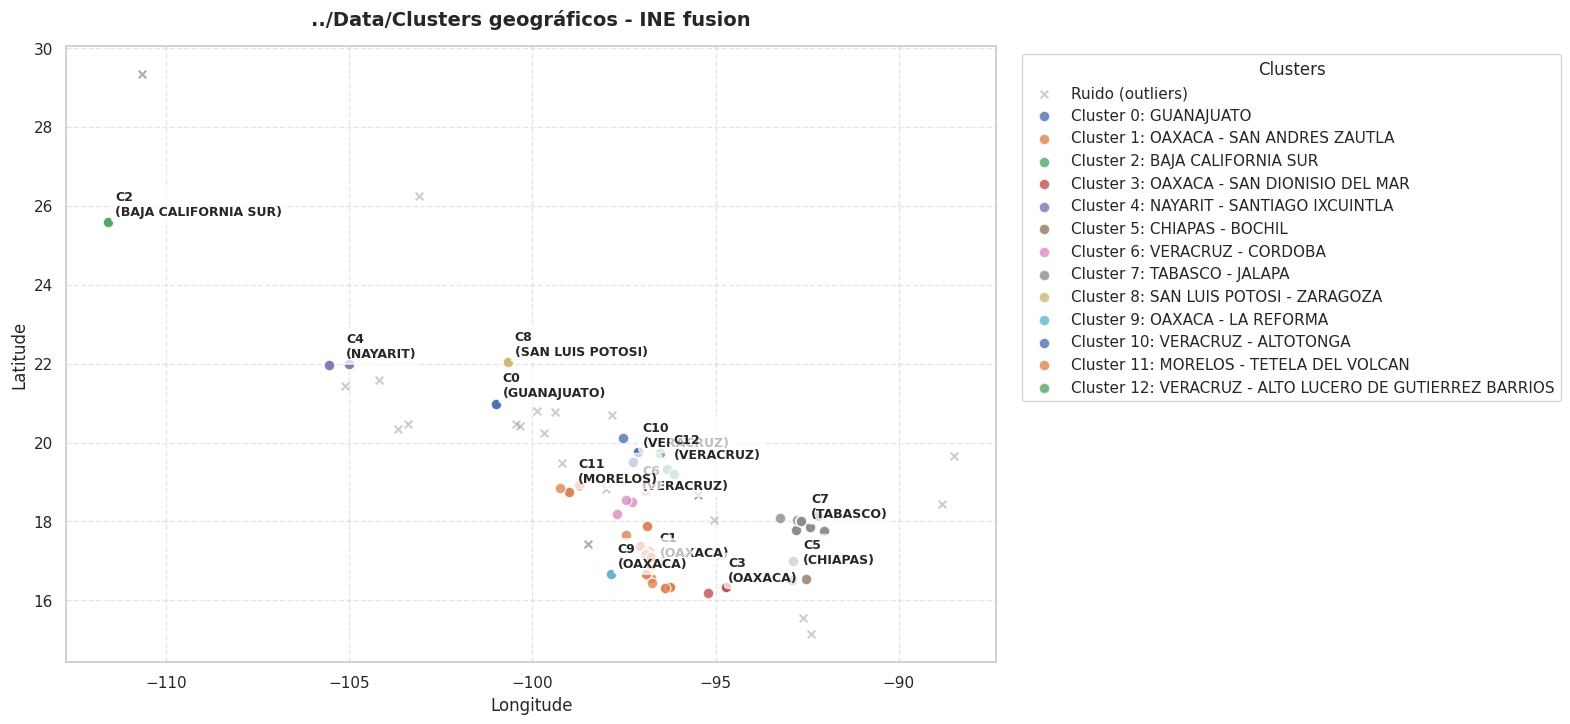

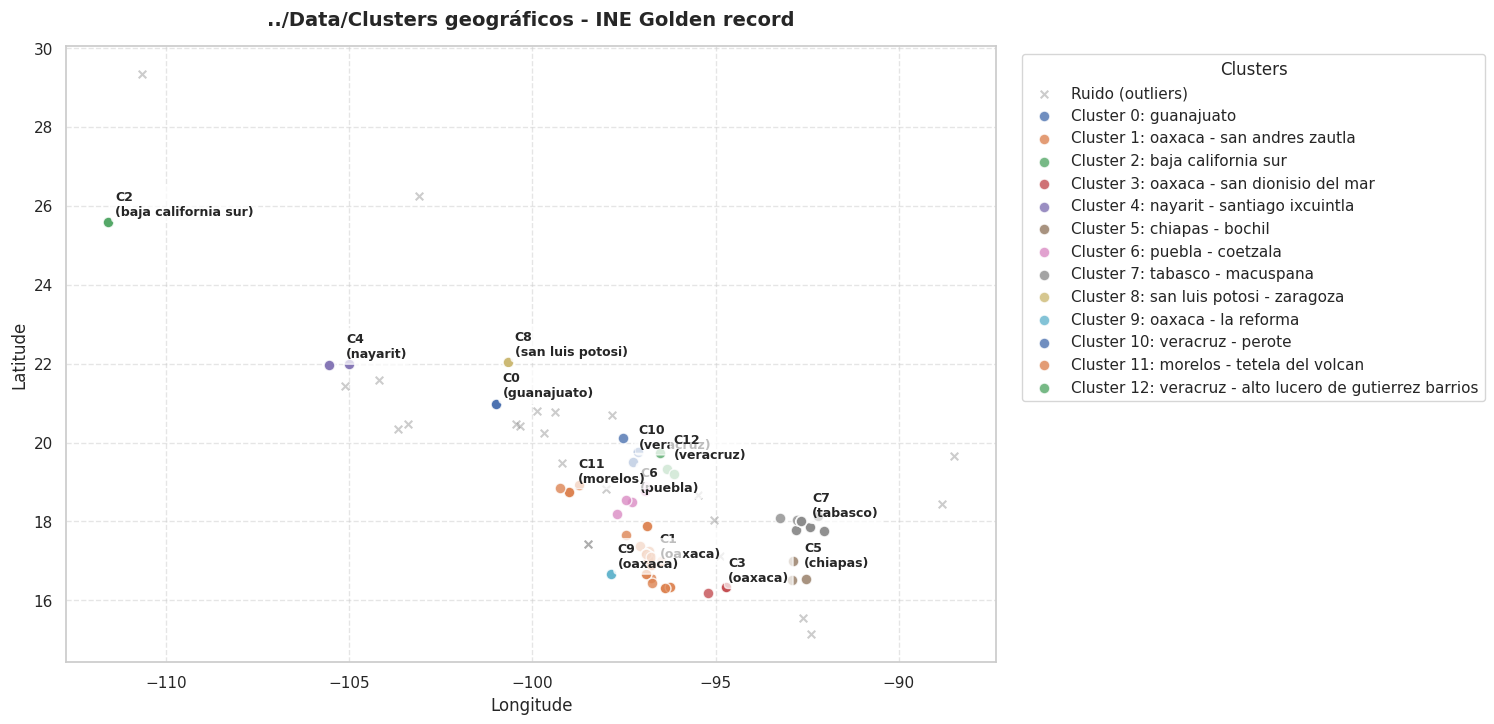

In [47]:
ine_fusion_geoclustering = cluster_geographically(
      ine_fusion_geo,
      plot_title=str(DATA_DIR / 'Clusters geográficos - INE fusion'),
      save_plot=True
  )
golden_g_geoclustering = cluster_geographically(
      golden_g_geo,
      plot_title=str(DATA_DIR / 'Clusters geográficos - INE Golden record'),
      save_plot=True
  )

### 4.2 Perfil estadístico integrado por estado

In [35]:
# Perfil estadístico por Estado
def pct_si(series):
    return (series.fillna('').astype(str).str.upper() == 'SI').mean()

perfil_base_estado = (
    matches_full
    .groupby(['estado_ine','vinculo_grupo_ine'])
    .agg(
        n_sanciones_ine   = ('idx_ine',        'nunique'),
        n_casos_banavim   = ('idx_bv',          'nunique'),
        edad_media_bv     = ('edad_bv',          'mean'),
        municipios_unicos = ('municipio_ine',    'nunique'),
    )
    .reset_index()
)
perfil_arma_estado = (
    matches_full
    .groupby(['estado_ine','vinculo_grupo_ine'])['Portaba Dicha Arma_bv']
    .apply(pct_si).reset_index()
    .rename(columns={'Portaba Dicha Arma_bv': 'pct_portaba_arma'})
)
perfil_alcohol_estado = (
    matches_full
    .groupby(['estado_ine','vinculo_grupo_ine'])['Droga_Alcohol_bv']
    .apply(pct_si).reset_index()
    .rename(columns={'Droga_Alcohol_bv': 'pct_alcohol'})
)
perfil_estado = (
    perfil_base_estado
    .merge(perfil_arma_estado,    on=['estado_ine','vinculo_grupo_ine'])
    .merge(perfil_alcohol_estado, on=['estado_ine','vinculo_grupo_ine'])
    .round(3)
    .sort_values('n_sanciones_ine', ascending=False)
)
print(f'Perfil por estado generado: {len(perfil_estado):,} grupos')
display(perfil_estado)

perfil_estado.to_csv(
    DATA_DIR / 'fusion_outputs' / 'perfil_estado_integrado.csv',
    index=False, encoding='utf-8-sig'
)
print('Guardado: perfil_estado_integrado.csv')

Perfil por estado generado: 12 grupos


,estado_ine,vinculo_grupo_ine,n_sanciones_ine,n_casos_banavim,edad_media_bv,municipios_unicos,pct_portaba_arma,pct_alcohol
4,OAXACA,PARES,9,10,31.784,3,0.000,0.0
3,OAXACA,JERARQUICA_SUBORDINACION,4,11,46.938,3,0.000,0.0
10,TABASCO,PARES,2,2,43.000,1,0.000,0.0
0,COAHUILA,PARES,1,1,28.000,1,0.000,0.0
2,MORELOS,JERARQUICA_SUBORDINACION,1,4,43.750,1,0.250,0.0
1,HIDALGO,JERARQUICA_SUBORDINACION,1,1,45.000,1,0.000,0.0
6,PUEBLA,PARES,1,1,50.000,1,1.000,0.0
5,PUEBLA,JERARQUICA_SUBORDINACION,1,2,41.000,1,0.500,0.0
7,QUINTANA ROO,OTRO,1,1255,37.254,1,0.023,0.0
8,SAN LUIS POTOSI,JERARQUICA_SUBORDINACION,1,1,47.000,1,0.000,0.0


Guardado: perfil_estado_integrado.csv


### 5. Matching Exacto (INE)

En lugar de similitud aproximada, decidimos intentar buscar registros con coincidencia exacta utilizando los campos estado_municipio, sexo y vinculo, con dos escenarios: alta confianza (ALTA) y alta + media confianza (ALTA_MEDIA).
Los resultados se interpretan como pares candidatos compatibles, no como identificaciones definitivas de personas.


### 5.1 Clasificación operativa del vínculo para matching

Se construyen los campos 'vinculo_match' y 'confianza_vinculo_match' directamente desde el campo 'vinculo_victima',
sin depender de 'vinculo_grupo'. La clasificación distingue categorías con alta equivalencia
semántica entre fuentes (confianza ALTA) de categorías residuales (confianza MEDIA).


In [36]:
def clasificar_vinculo_match(valor, fuente):
    if pd.isna(valor):
        return pd.Series({"vinculo_match": "NO_APTO_MATCH",
                          "confianza_vinculo_match": "NO_APTO"})
    v = str(valor).strip().upper()
    if v in {"", "NAN", "NONE", "SELECCIONE", "SIN DATO", "SIN DATOS",
             "NO ESPECIFICADO", "NO ESPECIFICADA", "NO SE ESPECIFICA"}:
        return pd.Series({"vinculo_match": "NO_APTO_MATCH",
                          "confianza_vinculo_match": "NO_APTO"})
    if fuente == "INE":
        if v == "PARES":
            return pd.Series({"vinculo_match": "PARES", "confianza_vinculo_match": "ALTA"})
        if v in {"JERARQUICA", "SUBORDINACION"}:
            return pd.Series({"vinculo_match": "JERARQUICA_SUBORDINACION",
                              "confianza_vinculo_match": "ALTA"})
        if v in {"OTRO", "OTRA", "OTRA RELACION"}:
            return pd.Series({"vinculo_match": "OTRO_RESIDUAL",
                              "confianza_vinculo_match": "MEDIA"})
        if v == "NINGUNA":
            return pd.Series({"vinculo_match": "SIN_RELACION_IDENTIFICABLE",
                              "confianza_vinculo_match": "MEDIA"})
    if fuente == "BANAVIM":
        if v in {"COMPANERO A", "COMPANERO", "COMPANERA"}:
            return pd.Series({"vinculo_match": "PARES", "confianza_vinculo_match": "ALTA"})
        if v in {"JEFE A O PATRON A", "JEFE A", "PATRON A", "JEFE", "PATRON"}:
            return pd.Series({"vinculo_match": "JERARQUICA_SUBORDINACION",
                              "confianza_vinculo_match": "ALTA"})
        if v in {"OTRO", "OTRA", "OTRA RELACION", "OTRO TIPO DE RELACION"}:
            return pd.Series({"vinculo_match": "OTRO_RESIDUAL",
                              "confianza_vinculo_match": "MEDIA"})
        if v == "DESCONOCIDO":
            return pd.Series({"vinculo_match": "SIN_RELACION_IDENTIFICABLE",
                              "confianza_vinculo_match": "MEDIA"})
    return pd.Series({"vinculo_match": "NO_APTO_MATCH", "confianza_vinculo_match": "NO_APTO"})

ine_fusion[["vinculo_match", "confianza_vinculo_match"]] = ine_fusion["vinculo_victima"].apply(
    lambda x: clasificar_vinculo_match(x, "INE"))
bv_fusion[["vinculo_match", "confianza_vinculo_match"]] = bv_fusion["vinculo_victima"].apply(
    lambda x: clasificar_vinculo_match(x, "BANAVIM"))

print("Distribución vinculo_match — INE:")
print(ine_fusion[["vinculo_match", "confianza_vinculo_match"]].value_counts(dropna=False).to_string())
print()
print("Distribución vinculo_match — BANAVIM:")
print(bv_fusion[["vinculo_match", "confianza_vinculo_match"]].value_counts(dropna=False).to_string())


Distribución vinculo_match — INE:
vinculo_match               confianza_vinculo_match
PARES                       ALTA                       61
SIN_RELACION_IDENTIFICABLE  MEDIA                      57
JERARQUICA_SUBORDINACION    ALTA                       38
OTRO_RESIDUAL               MEDIA                       4
NO_APTO_MATCH               NO_APTO                     2

Distribución vinculo_match — BANAVIM:
vinculo_match               confianza_vinculo_match
NO_APTO_MATCH               NO_APTO                    771103
OTRO_RESIDUAL               MEDIA                       31139
JERARQUICA_SUBORDINACION    ALTA                         1927
PARES                       ALTA                         1915
SIN_RELACION_IDENTIFICABLE  MEDIA                           8


In [37]:
def filtrar_base_match(df, niveles_confianza):
    mask = (
        df["confianza_vinculo_match"].isin(niveles_confianza)
        & df["sexo"].notna()
        & df["estado"].notna()
        & df["municipio"].notna()
        & df["vinculo_match"].notna()
    )
    return df.loc[mask].copy()

ine_match_alta       = filtrar_base_match(ine_fusion, ["ALTA"])
bv_match_alta        = filtrar_base_match(bv_fusion,  ["ALTA"])
ine_match_alta_media = filtrar_base_match(ine_fusion, ["ALTA", "MEDIA"])
bv_match_alta_media  = filtrar_base_match(bv_fusion,  ["ALTA", "MEDIA"])

resumen_bases_match = pd.DataFrame([
    {"escenario": "ALTA",       "base": "INE",     "registros": len(ine_match_alta),
     "pct_base_original": round(len(ine_match_alta)       / len(ine_fusion) * 100, 2)},
    {"escenario": "ALTA",       "base": "BANAVIM", "registros": len(bv_match_alta),
     "pct_base_original": round(len(bv_match_alta)        / len(bv_fusion)  * 100, 2)},
    {"escenario": "ALTA_MEDIA", "base": "INE",     "registros": len(ine_match_alta_media),
     "pct_base_original": round(len(ine_match_alta_media) / len(ine_fusion) * 100, 2)},
    {"escenario": "ALTA_MEDIA", "base": "BANAVIM", "registros": len(bv_match_alta_media),
     "pct_base_original": round(len(bv_match_alta_media)  / len(bv_fusion)  * 100, 2)},
])
display(resumen_bases_match)


,escenario,base,registros,pct_base_original
0,ALTA,INE,98,60.49
1,ALTA,BANAVIM,3824,0.47
2,ALTA_MEDIA,INE,128,79.01
3,ALTA_MEDIA,BANAVIM,34782,4.31


#### 5.2 Validación geográfica contra catálogo INEGI

Cada par 'estado + municipio' se valida contra el catálogo oficial de INEGI.
El catálogo se descarga una sola vez y se guarda en disco; ejecuciones posteriores usan
la copia en caché. Se aplican correcciones manuales para los municipios no encontrados
con variante de nombre conocida.


In [38]:
import unicodedata as _uc
import re as _re
import requests as _req
import time as _time

def normalizar_geo(s):
    if pd.isna(s): return ""
    s = str(s).strip().upper()
    s = "".join(c for c in _uc.normalize("NFD", s) if _uc.category(c) != "Mn")
    s = _re.sub(r"[^\w\s]", "", s)
    return _re.sub(r"\s+", " ", s).strip()

CVE_ENT = {
    "AGUASCALIENTES": "01", "BAJA CALIFORNIA": "02", "BAJA CALIFORNIA SUR": "03",
    "CAMPECHE": "04", "COAHUILA": "05", "COLIMA": "06", "CHIAPAS": "07",
    "CHIHUAHUA": "08", "CDMX": "09", "DURANGO": "10", "GUANAJUATO": "11",
    "GUERRERO": "12", "HIDALGO": "13", "JALISCO": "14", "MEXICO": "15",
    "MICHOACAN": "16", "MORELOS": "17", "NAYARIT": "18", "NUEVO LEON": "19",
    "OAXACA": "20", "PUEBLA": "21", "QUERETARO": "22", "QUINTANA ROO": "23",
    "SAN LUIS POTOSI": "24", "SINALOA": "25", "SONORA": "26", "TABASCO": "27",
    "TAMAULIPAS": "28", "TLAXCALA": "29", "VERACRUZ": "30", "YUCATAN": "31",
    "ZACATECAS": "32",
}

# ── Construir tabla de pares únicos para validación ──────────────────────────
def _pares_unicos(df_ine, df_bv, escenario):
    def _extract(df, base):
        return (df[["estado","municipio"]].drop_duplicates()
                  .assign(base=base, escenario=escenario))
    return pd.concat([_extract(df_ine, "INE"), _extract(df_bv, "BANAVIM")],
                     ignore_index=True)

pares_estado_municipio = pd.concat([
    _pares_unicos(ine_match_alta,       bv_match_alta,       "ALTA"),
    _pares_unicos(ine_match_alta_media, bv_match_alta_media, "ALTA_MEDIA"),
], ignore_index=True)
pares_estado_municipio["estado_norm"]    = pares_estado_municipio["estado"].apply(normalizar_geo)
pares_estado_municipio["municipio_norm"] = pares_estado_municipio["municipio"].apply(normalizar_geo)

# ── Catálogo INEGI (descarga con caché) ──────────────────────────────────────
_cat_path = DATA_DIR / "fusion_outputs" / "catalogo_inegi_municipios_usados.csv"
if _cat_path.exists():
    catalogo_inegi_municipios = pd.read_csv(_cat_path, encoding="utf-8-sig")
    print(f"Catálogo INEGI cargado desde caché: {catalogo_inegi_municipios.shape}")
else:
    print("Descargando catálogo INEGI...")
    _filas = []
    for est in sorted(pares_estado_municipio["estado_norm"].dropna().unique()):
        cve = CVE_ENT.get(est)
        if not cve:
            print(f"  Sin clave: {est}")
            continue
        try:
            r = _req.get(f"https://gaia.inegi.org.mx/wscatgeo/v2/mgem/{cve}", timeout=30)
            r.raise_for_status()
            data = r.json()
            muns = data.get("datos", data) if isinstance(data, dict) else data
            for m in muns:
                _filas.append({"estado": est, "cve_ent": m.get("cve_ent"),
                               "cve_mun": m.get("cve_mun"), "cvegeo": m.get("cvegeo"),
                               "municipio_inegi": m.get("nomgeo"),
                               "cabecera_inegi": m.get("nom_cab")})
            print(f"  {est}: {len(muns)} municipios")
        except Exception as e:
            print(f"  Error {est}: {e}")
        _time.sleep(0.2)
    catalogo_inegi_municipios = pd.DataFrame(_filas)
    catalogo_inegi_municipios["estado_norm"] = catalogo_inegi_municipios["estado"].apply(normalizar_geo)
    catalogo_inegi_municipios["municipio_inegi_norm"] = catalogo_inegi_municipios["municipio_inegi"].apply(normalizar_geo)
    catalogo_inegi_municipios.to_csv(_cat_path, index=False, encoding="utf-8-sig")
    print(f"Catálogo guardado: {catalogo_inegi_municipios.shape}")


Descargando catálogo INEGI...
  AGUASCALIENTES: 11 municipios
  BAJA CALIFORNIA: 7 municipios
  BAJA CALIFORNIA SUR: 5 municipios
  CAMPECHE: 13 municipios
  CDMX: 16 municipios
  CHIAPAS: 124 municipios
  CHIHUAHUA: 67 municipios
  COAHUILA: 38 municipios
  COLIMA: 10 municipios
  DURANGO: 39 municipios
  GUANAJUATO: 46 municipios
  GUERRERO: 85 municipios
  HIDALGO: 84 municipios
  JALISCO: 125 municipios
  MEXICO: 125 municipios
  MICHOACAN: 113 municipios
  MORELOS: 36 municipios
  NAYARIT: 20 municipios
  NUEVO LEON: 51 municipios
  OAXACA: 570 municipios
  PUEBLA: 217 municipios
  QUERETARO: 18 municipios
  QUINTANA ROO: 11 municipios
  SAN LUIS POTOSI: 59 municipios
  SINALOA: 20 municipios
  SONORA: 72 municipios
  TABASCO: 17 municipios
  TAMAULIPAS: 43 municipios
  TLAXCALA: 60 municipios
  VERACRUZ: 212 municipios
  YUCATAN: 106 municipios
  ZACATECAS: 58 municipios
Catálogo guardado: (2478, 8)


In [39]:
# Validación de pares estado+municipio contra catálogo INEGI
if "municipio_inegi_norm" not in catalogo_inegi_municipios.columns:
    catalogo_inegi_municipios["municipio_inegi_norm"] = (
        catalogo_inegi_municipios["municipio_inegi"].apply(normalizar_geo))

validacion_municipios = pares_estado_municipio.merge(
    catalogo_inegi_municipios[["estado_norm","municipio_inegi_norm",
                                "municipio_inegi","cve_ent","cve_mun","cvegeo"]],
    left_on=["estado_norm","municipio_norm"],
    right_on=["estado_norm","municipio_inegi_norm"],
    how="left"
)
validacion_municipios["existe_en_inegi"] = validacion_municipios["municipio_inegi"].notna()

print("Resumen de validación:")
display(validacion_municipios.groupby(["escenario","base","existe_en_inegi"]).size()
        .reset_index(name="n"))

# Correcciones manuales para municipios con variante de nombre conocida
_CORRECCIONES = {
    ("CAMPECHE", "CIUDAD DEL CARMEN"):          "CARMEN",
    ("CAMPECHE", "SAN FRANCISCO DE CAMPECHE"):  "CAMPECHE",
    ("CAMPECHE", "XPUJIL"):                     "CALAKMUL",
    ("COLIMA",   "CIUDAD DE ARMERIA"):           "ARMERIA",
    ("COLIMA",   "CIUDAD DE VILLA DE ALVAREZ"):  "VILLA DE ALVAREZ",
    ("NAYARIT",  "EL NAYAR"):                    "DEL NAYAR",
}

def _aplicar_correcciones(df):
    df = df.copy()
    for (est, mun_orig), mun_corr in _CORRECCIONES.items():
        mask = (df["estado"] == est) & (df["municipio"] == mun_orig)
        df.loc[mask, "municipio"] = mun_corr
    df["municipio_norm"] = df["municipio"].apply(normalizar_geo)
    return df

ine_match_alta       = _aplicar_correcciones(ine_match_alta)
bv_match_alta        = _aplicar_correcciones(bv_match_alta)
ine_match_alta_media = _aplicar_correcciones(ine_match_alta_media)
bv_match_alta_media  = _aplicar_correcciones(bv_match_alta_media)

# Agregar bandera municipio_validado_inegi
_muns_validados = (
    validacion_municipios[validacion_municipios["existe_en_inegi"]]
    [["estado","municipio"]].drop_duplicates()
    .assign(municipio_validado_inegi=True)
)

def _agregar_bandera(df):
    return df.merge(_muns_validados, on=["estado","municipio"], how="left").assign(
        municipio_validado_inegi=lambda d: d["municipio_validado_inegi"].fillna(False))

ine_match_alta       = _agregar_bandera(ine_match_alta)
bv_match_alta        = _agregar_bandera(bv_match_alta)
ine_match_alta_media = _agregar_bandera(ine_match_alta_media)
bv_match_alta_media  = _agregar_bandera(bv_match_alta_media)

print("Municipios validados — INE ALTA:", ine_match_alta["municipio_validado_inegi"].sum())
print("Municipios validados — BV ALTA: ", bv_match_alta["municipio_validado_inegi"].sum())


Resumen de validación:


,escenario,base,existe_en_inegi,n
0,ALTA,BANAVIM,False,6
1,ALTA,BANAVIM,True,465
2,ALTA,INE,False,3
3,ALTA,INE,True,37
4,ALTA_MEDIA,BANAVIM,False,8
5,ALTA_MEDIA,BANAVIM,True,1108
6,ALTA_MEDIA,INE,False,3
7,ALTA_MEDIA,INE,True,56


Municipios validados — INE ALTA: 95
Municipios validados — BV ALTA:  3736


/tmp/ipykernel_6070/1035542246.py:51: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  municipio_validado_inegi=lambda d: d["municipio_validado_inegi"].fillna(False))
/tmp/ipykernel_6070/1035542246.py:51: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  municipio_validado_inegi=lambda d: d["municipio_validado_inegi"].fillna(False))
/tmp/ipykernel_6070/1035542246.py:51: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the futur

#### 5.3 Candidatos exactos por escenario

Se realiza un join exacto sobre `estado_municipio + sexo + vinculo_match`. La salida contiene
pares candidatos compatibles etiquetados como 'CANDIDATO_EXACTO_ALTA' y 'CANDIDATO_REVISION_ALTA_MEDIA'.


In [40]:
def _asegurar_estado_municipio(df):
    df = df.copy()
    if "estado_municipio" not in df.columns:
        em = df["estado"].fillna("").str.strip() + " - " + df["municipio"].fillna("").str.strip()
        df["estado_municipio"] = em.where(em != " - ", np.nan)
    return df

def crear_candidatos_exactos(df_ine, df_bv, escenario_match, tipo_match):
    df_ine = _asegurar_estado_municipio(df_ine)
    df_bv  = _asegurar_estado_municipio(df_bv)
    campos = ["estado_municipio", "sexo", "vinculo_match"]
    ine_apto = df_ine.dropna(subset=campos).query("vinculo_match != 'NO_APTO_MATCH'").copy()
    bv_apto  = df_bv.dropna(subset=campos).query("vinculo_match != 'NO_APTO_MATCH'").copy()
    cands = ine_apto.merge(bv_apto, on=campos, how="inner", suffixes=("_ine","_bv"))
    cands["escenario_match"] = escenario_match
    cands["tipo_match"]      = tipo_match
    cands["requiere_revision_manual"] = True
    cols_prio = ["escenario_match","tipo_match","requiere_revision_manual",
                 "id_ine_caso","id_bv_caso","estado_municipio","sexo","vinculo_match",
                 "vinculo_victima_ine","vinculo_victima_bv",
                 "confianza_vinculo_match_ine","confianza_vinculo_match_bv",
                 "municipio_validado_inegi_ine","municipio_validado_inegi_bv"]
    cols_prio = [c for c in cols_prio if c in cands.columns]
    resto     = [c for c in cands.columns if c not in cols_prio]
    return cands[cols_prio + resto].copy()

matches_exactos_alta          = crear_candidatos_exactos(
    ine_match_alta, bv_match_alta, "ALTA_EXACTO", "CANDIDATO_EXACTO_ALTA")
candidatos_alta_media_revision = crear_candidatos_exactos(
    ine_match_alta_media, bv_match_alta_media, "ALTA_MEDIA_EXACTO", "CANDIDATO_REVISION_ALTA_MEDIA")

print(f"Pares ALTA_EXACTO       : {len(matches_exactos_alta):,}")
print(f"Pares ALTA_MEDIA_EXACTO : {len(candidatos_alta_media_revision):,}")
print(f"Casos INE únicos (alta) : {matches_exactos_alta['id_ine_caso'].nunique():,}")


Pares ALTA_EXACTO       : 8
Pares ALTA_MEDIA_EXACTO : 1,551
Casos INE únicos (alta) : 5


In [41]:
# Resumen de candidatos por caso INE y exportación de resultados
def resumen_candidatos_ine(candidatos, nombre):
    return (candidatos.groupby("id_ine_caso", dropna=False)
            .agg(n_candidatos_bv=("id_bv_caso","nunique"),
                 estado_municipio=("estado_municipio","first"),
                 sexo=("sexo","first"),
                 vinculo_match=("vinculo_match","first"))
            .reset_index()
            .sort_values("n_candidatos_bv", ascending=False)
            .assign(escenario=nombre))

resumen_alta = resumen_candidatos_ine(matches_exactos_alta, "ALTA_EXACTO")
resumen_alta_media = resumen_candidatos_ine(candidatos_alta_media_revision, "ALTA_MEDIA_EXACTO")
print("Distribución de candidatos por caso INE — escenario ALTA:")
display(resumen_alta.head(15))

# Tabla de revisión final con columna de decisión pendiente
def construir_tabla_revision(candidatos):
    cols = ["id_ine_caso","id_bv_caso","escenario_match","tipo_match",
            "estado_municipio","sexo","vinculo_match",
            "vinculo_victima_ine","vinculo_victima_bv",
            "confianza_vinculo_match_ine","confianza_vinculo_match_bv",
            "municipio_validado_inegi_ine","municipio_validado_inegi_bv"]
    tabla = candidatos[[c for c in cols if c in candidatos.columns]].drop_duplicates().copy()
    tabla["decision_revision_manual"] = "PENDIENTE_REVISION"
    tabla["comentario_revision"] = ""
    return tabla

tabla_revision_alta = construir_tabla_revision(matches_exactos_alta)
tabla_revision_alta.to_csv(
    DATA_DIR / "fusion_outputs" / "tabla_revision_manual_alta_exacta.csv",
    index=False, encoding="utf-8-sig")

matches_exactos_alta.to_csv(
    DATA_DIR / "fusion_outputs" / "matches_exactos_alta_confianza.csv",
    index=False, encoding="utf-8-sig")

# Resumen comparativo de ambos escenarios
def _n_validados_ambas(cands):
    c_i, c_b = "municipio_validado_inegi_ine", "municipio_validado_inegi_bv"
    if c_i not in cands.columns or c_b not in cands.columns: return np.nan
    return int((cands[c_i].fillna(False).astype(bool) & cands[c_b].fillna(False).astype(bool)).sum())

resumen_matching_exacto = pd.DataFrame([
    {"escenario": "ALTA_EXACTO",
     "registros_ine": len(ine_match_alta), "registros_bv": len(bv_match_alta),
     "pares_candidatos": len(matches_exactos_alta),
     "casos_ine_con_candidato": matches_exactos_alta["id_ine_caso"].nunique(),
     "pares_municipio_validado_ambas": _n_validados_ambas(matches_exactos_alta),
     "interpretacion": "Resultado principal: vínculo de alta confianza, coincidencia exacta."},
    {"escenario": "ALTA_MEDIA_EXACTO",
     "registros_ine": len(ine_match_alta_media), "registros_bv": len(bv_match_alta_media),
     "pares_candidatos": len(candidatos_alta_media_revision),
     "casos_ine_con_candidato": candidatos_alta_media_revision["id_ine_caso"].nunique(),
     "pares_municipio_validado_ambas": _n_validados_ambas(candidatos_alta_media_revision),
     "interpretacion": "Escenario de sensibilidad; categorías OTRO y SIN_RELACION incluidas."},
])
display(resumen_matching_exacto)
resumen_matching_exacto.to_csv(
    DATA_DIR / "fusion_outputs" / "resumen_matching_exacto.csv",
    index=False, encoding="utf-8-sig")
print("Archivos exportados a fusion_outputs/")


Distribución de candidatos por caso INE — escenario ALTA:


,id_ine_caso,n_candidatos_bv,estado_municipio,sexo,vinculo_match,escenario
3,INE_00075,4,MORELOS - TETELA DEL VOLCAN,H,JERARQUICA_SUBORDINACION,ALTA_EXACTO
0,INE_00042,1,HIDALGO - ZIMAPAN,H,JERARQUICA_SUBORDINACION,ALTA_EXACTO
1,INE_00055,1,VERACRUZ - PEROTE,H,PARES,ALTA_EXACTO
2,INE_00074,1,COAHUILA - FRANCISCO I MADERO,H,PARES,ALTA_EXACTO
4,INE_00136,1,PUEBLA - FRANCISCO Z MENA,H,JERARQUICA_SUBORDINACION,ALTA_EXACTO


,escenario,registros_ine,registros_bv,pares_candidatos,casos_ine_con_candidato,pares_municipio_validado_ambas,interpretacion
0,ALTA_EXACTO,98,3824,8,5,8,"Resultado principal: vínculo de alta confianza, coincidencia exacta."
1,ALTA_MEDIA_EXACTO,128,34782,1551,7,1551,Escenario de sensibilidad; categorías OTRO y SIN_RELACION incluidas.


Archivos exportados a fusion_outputs/
